This notebook is to present an example of how to generate meshes starting from CT images.The details of the different steps can be found in the report.This includs starting from a CT image, chosing a zone we want to corp (say for example the  torso between vertebrae_T3 and vertebrae_L1 ),extract the 3D mask of that zone,and build meshes of all the 2D slices of that zone.

The statring point is a CT scan ( file CT.nii.gz), with the segmentations of the structures( heart.nii.gz, kidney.nii.gz etc).For the version of library we have now,We used the training set of *TotalSegmentor*;a deep-learning based software for segmenting CT (and also MRI I think) scans.(https://github.com/wasserth/TotalSegmentator).
You can extand the library with any other CT scans and use *TotalSegmentor* on them, but then that would further depend on the segmentation accuracy.



In [6]:
import sys, os
import numpy as np
import argparse
import pickle
from pyeit.mesh import PyEITMesh
import pyeit.mesh as mesh
from pyeit.eit.interp2d import sim2pts
from pyeit.eit.protocol import PyEITProtocol
from pyeit.visual.plot    import create_mesh_plot, create_plot
from pyeit.mesh.shape import *
from pyeit.mesh.utils import edge_list
from pyeit.mesh import PyEITMesh



Define the list of organs that could be present in the CT scans of the initial CT dataset:

In [2]:
ORGANS = {
    "adrenal_gland": [
        "adrenal_gland_left.nii.gz",
        "adrenal_gland_right.nii.gz",
    ],
    "atrial_appendage": [
        "atrial_appendage_left.nii.gz",
        "atrial_appendage_right.nii.gz",
    ],
    "autochthon": [
        "autochthon_left.nii.gz",
        "autochthon_right.nii.gz",
    ],
    "brain": [
        "brain.nii.gz",
    ],
    "aorta": [
        "aorta.nii.gz",
    ],
    "brachiocephalic_trunk": [
        "brachiocephalic_trunk.nii.gz",
    ],
    "brachiocephalic_vein": [
        "brachiocephalic_vein_left.nii.gz",
        "brachiocephalic_vein_right.nii.gz",
    ],
    "clavicula": [
        "clavicula_left.nii.gz",
        "clavicula_right.nii.gz",
    ],
    "colon": [
        "colon.nii.gz",
    ],
    "common_carotid_artery": [
        "common_carotid_artery_left.nii.gz",
        "common_carotid_artery_right.nii.gz",
    ],
    "costal_cartilages": [
        "costal_cartilages.nii.gz",
    ],
    "duodenum": [
        "duodenum.nii.gz",
    ],
    "esophagus": [
        "esophagus.nii.gz",
    ],
    "femur": [
        "femur_left.nii.gz",
        "femur_right.nii.gz",
    ],
    "gallbladder": [
        "gallbladder.nii.gz",
    ],
    "gluteus_maximus": [
        "gluteus_maximus_left.nii.gz",
        "gluteus_maximus_right.nii.gz",
    ],
    "gluteus_medius": [
        "gluteus_medius_left.nii.gz",
        "gluteus_medius_right.nii.gz",
    ],
    "gluteus_minimus": [
        "gluteus_minimus_left.nii.gz",
        "gluteus_minimus_right.nii.gz",
    ],
    "heart": [
        "heart.nii.gz",
    ],
    "hip": [
        "hip_left.nii.gz",
        "hip_right.nii.gz",
    ],
    "humerus": [
        "humerus_left.nii.gz",
        "humerus_right.nii.gz",
    ],
    "iliac_artery": [
        "iliac_artery_left.nii.gz",
        "iliac_artery_right.nii.gz",
    ],
    "iliac_vena": [
        "iliac_vena_left.nii.gz",
        "iliac_vena_right.nii.gz",
    ],
    "iliopsoas": [
        "iliopsoas_left.nii.gz",
        "iliopsoas_right.nii.gz",
    ],
    "inferior_vena_cava": [
        "inferior_vena_cava.nii.gz",
    ],
    "kidney": [
        "kidney_left.nii.gz",
        "kidney_right.nii.gz",
    ],
    "kidney_cyst": [
        "kidney_cyst_left.nii.gz",
        "kidney_cyst_right.nii.gz",
    ],
    "lung": [
        "lung_lower_lobe_left.nii.gz",
        "lung_lower_lobe_right.nii.gz",
        "lung_middle_lobe_right.nii.gz",
        "lung_upper_lobe_left.nii.gz",
        "lung_upper_lobe_right.nii.gz",
    ],
    "pancreas": [
        "pancreas.nii.gz",
    ],
    "pulmonary_vein": [
        "pulmonary_vein.nii.gz",
    ],
    "portal_and_splenic_vein": [
        "portal_vein_and_splenic_vein.nii.gz",
    ],
    "prostate": [
        "prostate.nii.gz",
    ],
    "ribs": [
        "rib_left_1.nii.gz",  "rib_left_2.nii.gz",  "rib_left_3.nii.gz",
        "rib_left_4.nii.gz",  "rib_left_5.nii.gz",  "rib_left_6.nii.gz",
        "rib_left_7.nii.gz",  "rib_left_8.nii.gz",  "rib_left_9.nii.gz",
        "rib_left_10.nii.gz", "rib_left_11.nii.gz", "rib_left_12.nii.gz",
        "rib_right_1.nii.gz", "rib_right_2.nii.gz", "rib_right_3.nii.gz",
        "rib_right_4.nii.gz", "rib_right_5.nii.gz", "rib_right_6.nii.gz",
        "rib_right_7.nii.gz", "rib_right_8.nii.gz", "rib_right_9.nii.gz",
        "rib_right_10.nii.gz","rib_right_11.nii.gz","rib_right_12.nii.gz",
    ],
    "sacrum": [
        "sacrum.nii.gz",
    ],
    "scapula": [
        "scapula_left.nii.gz",
        "scapula_right.nii.gz",
    ],
    "small_bowel": [
        "small_bowel.nii.gz",
    ],
    "spinal_cord": [
        "spinal_cord.nii.gz",
    ],
    "spleen": [
        "spleen.nii.gz",
    ],
    "sternum": [
        "sternum.nii.gz",
    ],
    "stomach": [
        "stomach.nii.gz",
    ],
    "subclavian_artery": [
        "subclavian_artery_left.nii.gz",
        "subclavian_artery_right.nii.gz",
    ],
    "superior_vena_cava": [
        "superior_vena_cava.nii.gz",
    ],
    "thyroid_gland": [
        "thyroid_gland.nii.gz",
    ],
    "trachea": [
        "trachea.nii.gz",
    ],
    "urinary_bladder": [
        "urinary_bladder.nii.gz",
    ],
    "vertebrae": [
        "vertebrae_C1.nii.gz",  "vertebrae_C2.nii.gz",  "vertebrae_C3.nii.gz",
        "vertebrae_C4.nii.gz",  "vertebrae_C5.nii.gz",  "vertebrae_C6.nii.gz",
        "vertebrae_C7.nii.gz",  "vertebrae_L1.nii.gz",  "vertebrae_L2.nii.gz",
        "vertebrae_L3.nii.gz",  "vertebrae_L4.nii.gz",  "vertebrae_L5.nii.gz",
        "vertebrae_S1.nii.gz",  "vertebrae_T1.nii.gz",  "vertebrae_T2.nii.gz",
        "vertebrae_T3.nii.gz",  "vertebrae_T4.nii.gz",  "vertebrae_T5.nii.gz",
        "vertebrae_T6.nii.gz",  "vertebrae_T7.nii.gz",  "vertebrae_T8.nii.gz",
        "vertebrae_T9.nii.gz",  "vertebrae_T10.nii.gz", "vertebrae_T11.nii.gz",
        "vertebrae_T12.nii.gz",
    ],
    "liver": ["liver.nii.gz"]
    }


In [ ]:
from src.mesh_generating_functions import compute_z_bounds, organs_present_in_crop,Get_all_masks


case_id= "s0011"  ## number of case (CT)
ct_path= os.path.join("Data_set", case_id, "ct.nii.gz") #To adapt to wherever you have the folder "s0011"
seg_dir = os.path.join("Data_set", case_id, "segmentations") ## paths to CT image and segmentations, to adapt

_, z_min, z_max,_ = compute_z_bounds(ct_path, seg_dir, top="vertebrae_T3", bottom="vertebrae_L1", margin=0)   ## zone you want to crop , fore example here is between vertebrae_T3 and vertebrae_L1#
present_organs = organs_present_in_crop(seg_dir, z_min, z_max, ORGANS) ## List of organs present in the cropped zone ##

mask3d  = Get_all_masks(case_id, present_organs, ORGANS) ## 3D mask of the cropped zone ##



In [ ]:
from src.mesh_generating_functions import build_and_store_meshes

##

mask,mesh_obj,barsA = build_and_store_meshes(   
        case_id        = case_id,   ## case number, e.g "s0059"
        base_dir       = "Data_set",   ## name of the folder where you have the folder like  "s0059",inside of which you have ct.nii.gz and segmentations
        organs         = ORGANS,
        slice_index    = z_min+1, ## choose one slice, just for an example. you can modify it or loop on all slices etc 
        z_min          =z_min,   
        z_max          =z_max,  ## z_min and z_max are not relevelnt here.They were when producing the library(saving them in the files).
        mask3d         = mask3d,  ## 3D mask of the corpped zone
        present_organs = present_organs, ## same for z_min and z_max
        n_el           = 16,  ## number of electrodes (see note below)
        h0             = 0.025, ## resolution; this is the maximum lenght of edges allowed, in a normalized domain([-1,1] in the mesh).this is the only parameters I chose 
                                ## to modify.
        output_dir     = "aa"  ## We don't save anything here, so we can put whatever. you can uncomment the lines of code that save a file in the fucntion
                                ## build_and_store_meshes
)

## do the same for a diffrenet resolution
mask_1,mesh_obj_1,barsB= build_and_store_meshes(
        case_id        = case_id,
        base_dir       = "Data_set",
        organs         = ORGANS,
        slice_index    = z_min+1,
        z_min          =z_min,
        z_max          =z_max, 
        mask3d         = mask3d,
        present_organs = present_organs,
        n_el           = 16,
        h0             = 0.25,
        output_dir     = "aa"
)

==> Traitement de s0011 slice 204
mask de la slice 204crée !
mesh de la slice 204 géneré !
==> Traitement de s0011 slice 204
mask de la slice 204crée !
mesh de la slice 204 géneré !


**A small note on Pygalmesh** ((https://github.com/meshpro/pygalmesh).): I find it to be a really good choice.It is back-ended with a C++ coded library(called CGAL) so it is pretty fast.Also it allows to choose many parameters(Please check the documentation).For example , DistMesh(pyeit)relies on an iterative force-based point relaxation scheme that produces uniform triangle sizes, so the convergence of the Delaunay triangulation can be really slow, which is not the case for Pygalmesh.You are free to discover other tools.Here is a performances comparasion of commun meshing tools in python: https://github.com/meshpro/meshgen-comparison


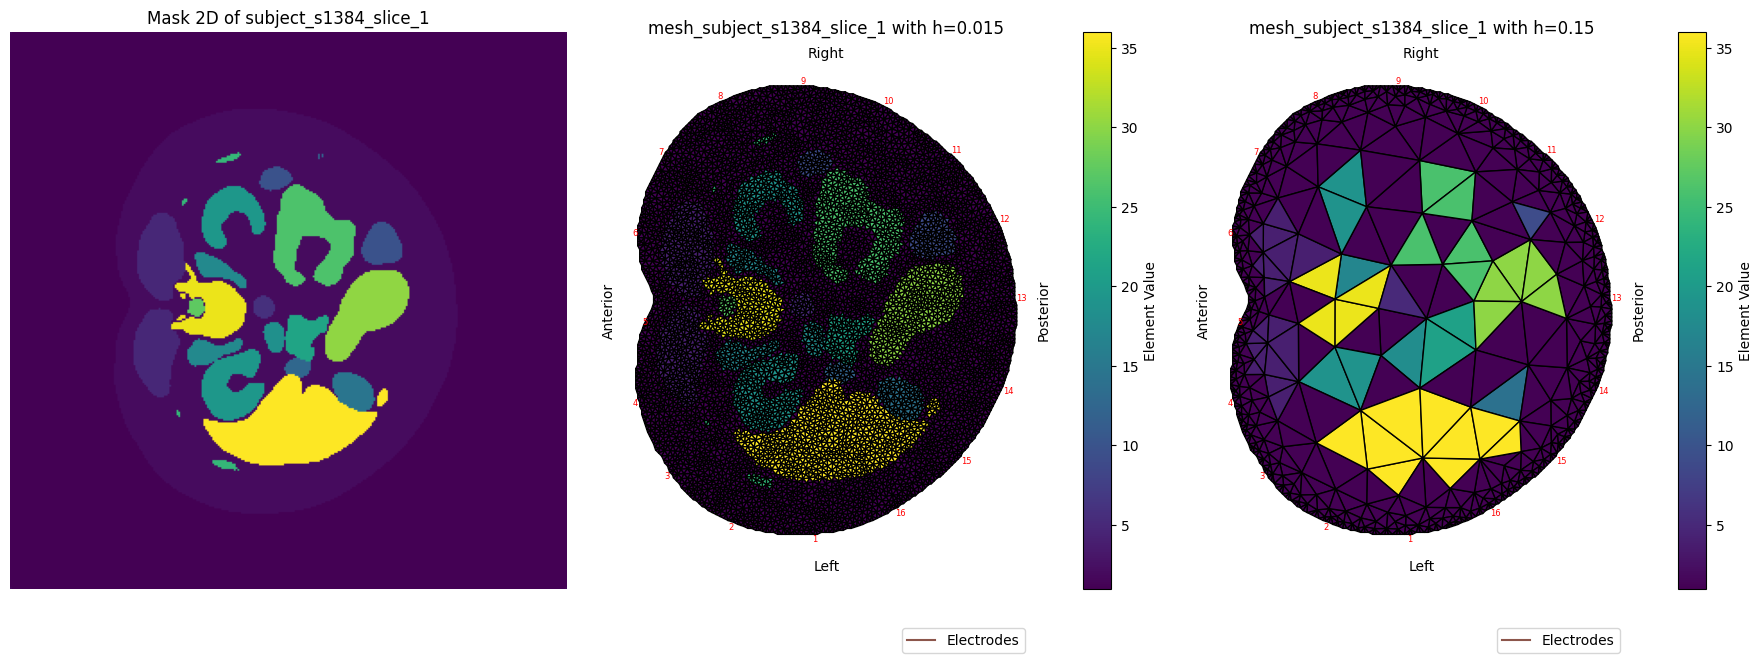

In [ ]:
## Plots
import matplotlib.pyplot as plt




fig, (ax0,ax1,ax2) = plt.subplots(1, 3, figsize=(18, 6))
    
ax0.imshow(mask, cmap='viridis')
ax0.set_title("Mask 2D of subject_s1384_slice_1")
ax0.axis("off")
  
create_mesh_plot(
                    ax1,mesh_obj,
                    electrodes=mesh_obj.el_pos,
                    coordinate_labels="radiological",
                    marker_text_kwargs={"color": "red", "fontsize": 6}
)
ax1.set_title("mesh_subject_s1384_slice_1 with h=0.015")
ax1.axis("off")


create_mesh_plot(
                    ax2,mesh_obj_1,
                    electrodes=mesh_obj_1.el_pos,
                    coordinate_labels="radiological",
                    marker_text_kwargs={"color": "red", "fontsize": 6}
        )
ax2.set_title("mesh_subject_s1384_slice_1 with h=0.15")
ax2.axis("off")



plt.tight_layout()
plt.show()

The figure above show the impact of the choice of resolution.As mentionned in the report, it was done automatically after estimating the minimum number of pixels a structre occupies when generating the meshes of the library

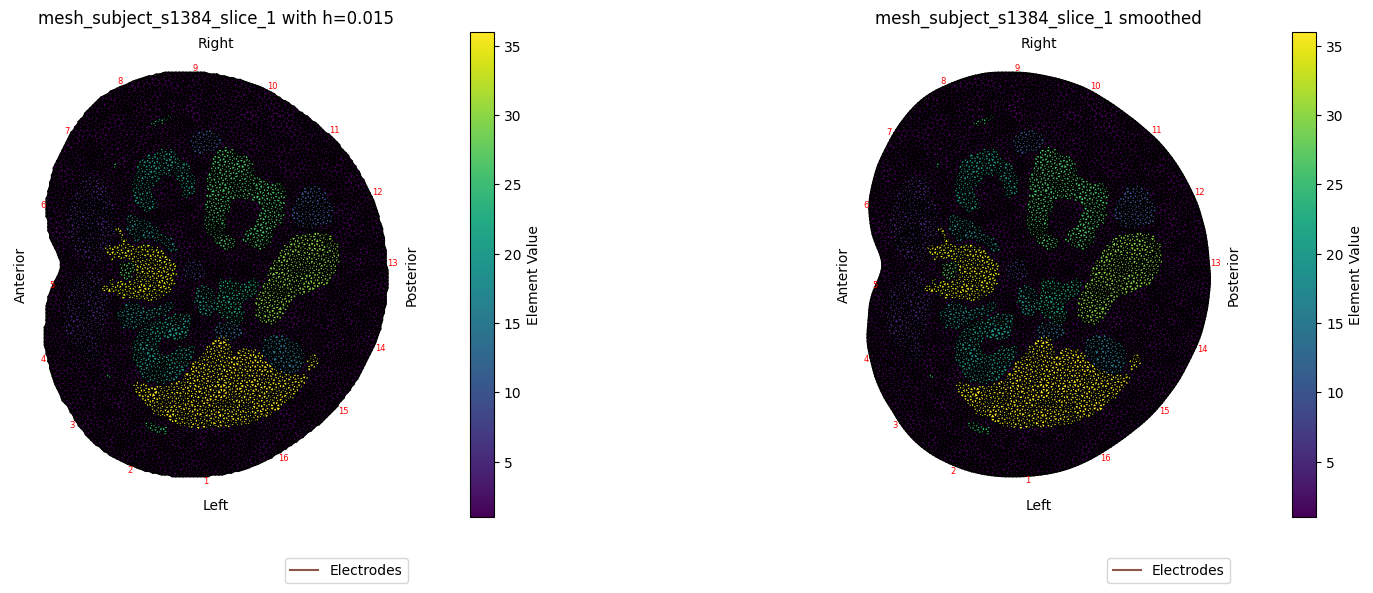

In [ ]:
### smoothing the mesh boundary ##
from src.mesh_post_processing import smooth_mesh_boundary

meshA_smooth = smooth_mesh_boundary(mesh_obj, iterations=10, alpha=0.7,bars=barsA)  ## check code in mesh_post_processing ##

fig, (ax1,ax2 )= plt.subplots(1, 2, figsize=(18, 6))
  
create_mesh_plot(
                    ax1,mesh_obj,
                    electrodes=mesh_obj.el_pos,
                    coordinate_labels="radiological",
                    marker_text_kwargs={"color": "red", "fontsize": 6}
)
ax1.set_title("mesh_subject_s1384_slice_1 with h=0.015")
ax1.axis("off")


create_mesh_plot(
                    ax2,meshA_smooth,
                    electrodes=meshA_smooth.el_pos,
                    coordinate_labels="radiological",
                    marker_text_kwargs={"color": "red", "fontsize": 6}
        )
ax2.set_title("mesh_subject_s1384_slice_1 smoothed")
ax2.axis("off")
plt.tight_layout()

plt.show()


Below is an example of to implement a non rigid transformation to map the content of a slice to the bounday of another. That was useful in the context of reconstructing solution by search.When solving the forward problem on all slices and comparing their EIT meausrmenbts with the reference slice,each one of them have a diffrent domain.So we fix a boundary which is the one of the reference slice,map the content of all slices to that domain and slove the forward problem, and then give the best fits.

In [ ]:
from src.mesh_post_processing import extract_ordered_boundary, resample_contour_by_arclength, align_contours, ThinPlateSpline2D


bnd_idx_A, bnd_pts_A = extract_ordered_boundary(mesh_obj_1,barsB)
bnd_idx_B, bnd_pts_B = extract_ordered_boundary(meshA_smooth,barsA) ## first extract the coordinates and indexes of points on the boundary


N = 400
src = resample_contour_by_arclength(bnd_pts_A, N)
dst = resample_contour_by_arclength(bnd_pts_B, N) ## resampling: beacause two meshes have different numbers of points on the boundary.


src_aligned, shift, was_reversed = align_contours(src, dst)   ## align the two set of points: the transformation estimates a rotation angle,so
                                                                ## alignement is important

# src= meshA.node[meshA.el_pos, :2]  # on ne garde que les 2 premières colonnes (x,y)
# dst= meshB.node[meshB.el_pos, :2]  # on ne garde que les 2 premières colonnes (x,y)


tps = ThinPlateSpline2D()
tps.fit(src_aligned, dst) ## define the transformation operator, then find the optimal parameters that map src_aligned to dst
       
nodesA_warp = tps.transform(mesh_obj_1.node[:,:2])  # and finally map the content of the whole first mesh by the same transormation: that gives the 
                                                    # new coordinates of the nodes of the mesh
        
meshC = PyEITMesh(
        node    =  nodesA_warp,
        element = mesh_obj_1.element,
        el_pos  = mesh_obj_1.el_pos
)
meshC.perm = mesh_obj_1.perm

In [ ]:
## plots
fig, (ax0,ax1,ax2 )= plt.subplots(1, 3, figsize=(18, 6))
  
create_mesh_plot(
                    ax0,mesh_obj_1,
                    electrodes=mesh_obj_1.el_pos,
                    coordinate_labels="radiological",
                    marker_text_kwargs={"color": "red", "fontsize": 6}
)
ax0.set_title("mesh_subject_s0070_slice_1")
ax0.axis("off")


create_mesh_plot(
                    ax1,meshA_smooth,
                    electrodes=meshA_smooth.el_pos,
                    coordinate_labels="radiological",
                    marker_text_kwargs={"color": "red", "fontsize": 6}
        )
ax1.set_title("mesh_subject_s1384_slice_1")
ax1.axis("off")

create_mesh_plot(
                    ax2,meshC,
                    electrodes=meshC.el_pos,
                    coordinate_labels="radiological",
                    marker_text_kwargs={"color": "red", "fontsize": 6}
        )
ax2.set_title("mesh_subject_s0070_slice_1 transformed")
ax2.axis("off")

plt.tight_layout()
plt.show()